In [1]:
import warnings
get_ipython().run_line_magic('run', '"/media/nbourg/One Touch/PhD/Separation_HFR_EAC/toolbox.ipynb"')
warnings.filterwarnings('ignore')

# Raw vs. filled data availability

For the DINEOF run, you need to chose a threshold of temporal coverage under which you mask your data. We choose a lower one for RRK simply because there is less data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import xarray as xr
import pandas as pd
import glob 

path = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/HFR/Radials/'
path_vectors = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/HFR/Vectors_Filled/'

rrk_daily = xr.open_dataset(path+'RRK'+'/QCed/RRK_daily_Y2019_M07_Y2021_M12.nc')
nnb_daily = xr.open_dataset(path+'NNB'+'/QCed/NNB_daily_Y2019_M07_Y2021_M12.nc')

currents = xr.open_dataset(path_vectors+'currents_dineof_COFFS_Y2019M07_Y2020M12.nc')

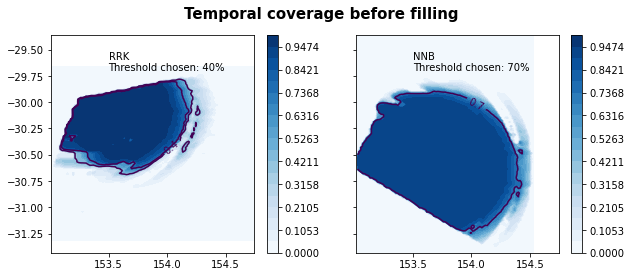

In [3]:
fig,axs = plt.subplots(ncols=2,sharex=True,sharey=True,figsize=(10,4))
#RRK
pc0=axs[0].contourf(rrk_daily['lon'],
           rrk_daily['lat'],
           get_pixel_coverage(rrk_daily['vr'].values[:550])/550,
                   levels=np.linspace(0,1,20),cmap='Blues')

CS = axs[0].contour(rrk_daily['lon'],
           rrk_daily['lat'],
           get_pixel_coverage(rrk_daily['vr'].values[:550])/550, [0.4])

CSbis = axs[0].contour(rrk_daily['lon'],
           rrk_daily['lat'],
           get_pixel_coverage(rrk_daily['vr'].values[:550])/550, [0.7])

axs[0].clabel(CS, inline=True, fontsize=10)
axs[0].text(153.5,-29.7,'RRK\nThreshold chosen: 40%')


#NNB
pc1=axs[1].contourf(nnb_daily['lon'],
           nnb_daily['lat'],
           get_pixel_coverage(nnb_daily['vr'].values[:550])/550,
                   levels=np.linspace(0,1,20),cmap='Blues')
CS1 = axs[1].contour(nnb_daily['lon'],
           nnb_daily['lat'],
           get_pixel_coverage(nnb_daily['vr'][:550])/550,[0.7])

axs[1].clabel(CS1, inline=True, fontsize=10)
axs[1].text(153.5,-29.7,'NNB\nThreshold chosen: 70%')

fig.suptitle('Temporal coverage before filling',fontsize=15,fontweight='bold')
fig.colorbar(pc0,ax=axs[0])
fig.colorbar(pc1,ax=axs[1])

Text(0.5, 1.0, 'Currents Filled')

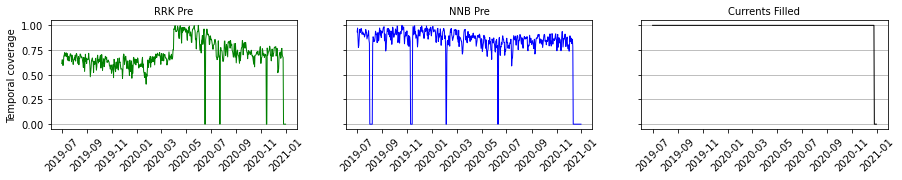

In [4]:
fig,axs = plt.subplots(ncols=3,sharex=True,sharey=True,figsize=(15,2))
for ax in fig.get_axes():
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.grid(zorder=0)

axs[0].plot(rrk_daily['time'].values[:550],
        get_spatial_coverage(rrk_daily['vr'].values[:550])/np.nanmax(get_spatial_coverage(rrk_daily['vr'].values[:550])),
        linewidth=1,
        color='g',
       zorder=3)

axs[1].plot(nnb_daily['time'].values[:550],
        get_spatial_coverage(nnb_daily['vr'].values[:550])/np.nanmax(get_spatial_coverage(nnb_daily['vr'].values[:550])),
        linewidth=1,
        color='b',
       zorder=3)

axs[2].plot(currents['time'].values,
        get_spatial_coverage(currents['v'].values)/np.nanmax(get_spatial_coverage(currents['v'].values)),
        linewidth=1,
        color='k',
       zorder=3)

axs[0].set_ylabel('Temporal coverage')
axs[0].set_title('RRK Pre',fontsize=10)
axs[1].set_title('NNB Pre',fontsize=10)
axs[2].set_title('Currents Filled', fontsize=10)


## Example: Timeseries of the velocity at a pixel filled by dineof (blue) vs raw (orange)

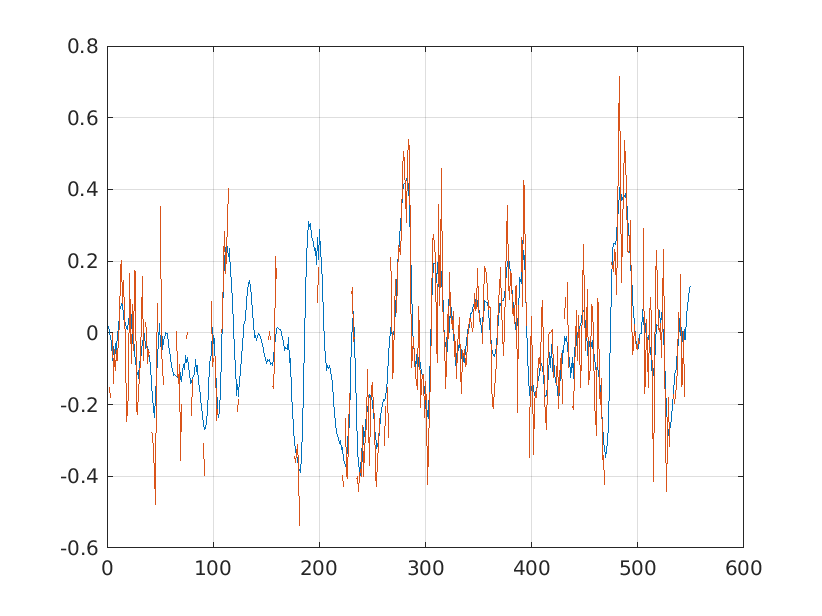

# Some checks with chl-a data, eddies, upwellings

In [5]:
from matplotlib.colors import LinearSegmentedColormap

def build_cmap(name, colors, N=100, reverse=''):
        if reverse == 'r':
                colors = [colors[len(colors)-1-i] for i in range(0, len(colors))]
                cmap = LinearSegmentedColormap.from_list(name, colors, N=N)
        else:
                cmap = LinearSegmentedColormap.from_list(name, colors, N=N)
        return cmap

        
cmap_chl = build_cmap('natacha', [(0/256, 5/256, 34/256),(34/256, 106/256, 234/256),
                (86/256, 196/256, 227/256),(122/256, 218/256, 166/256),
                (246/256, 252/256, 181/256), (255/256, 255/256, 255/256)])


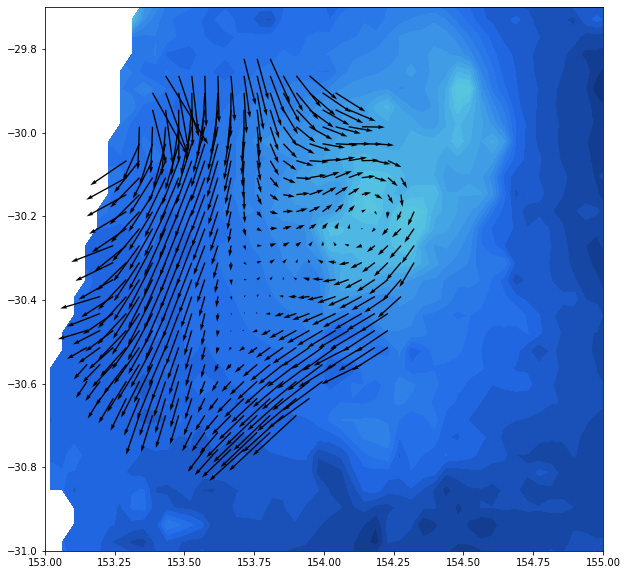

In [6]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2020_07.nc')
step=3
fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(153,155)
ax.set_ylim(-31,-29.7)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][11-1].values),levels=np.linspace(-1,.5,50),cmap=cmap_chl)
q=ax.quiver(currents['lon'][::step,::step],
            currents['lat'][::step,::step],
            currents['u'][377-1,::step,::step],
            currents['v'][377-1,::step,::step],units='inches',scale=.5)


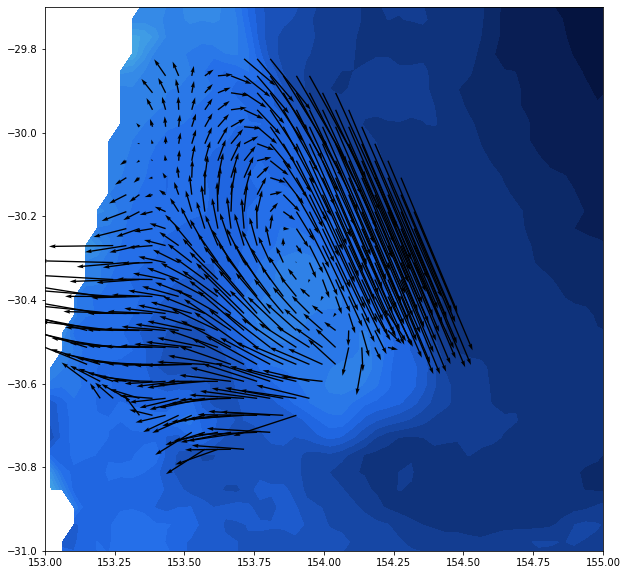

In [7]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2020_10.nc')
step=3
fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(153,155)
ax.set_ylim(-31,-29.7)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][30-1].values),levels=np.linspace(-1.2,.8,50),cmap=cmap_chl)
q=ax.quiver(currents['lon'][::step,::step],
            currents['lat'][::step,::step],
            currents['u'][488-1,::step,::step],
            currents['v'][488-1,::step,::step],units='inches',scale=.5)


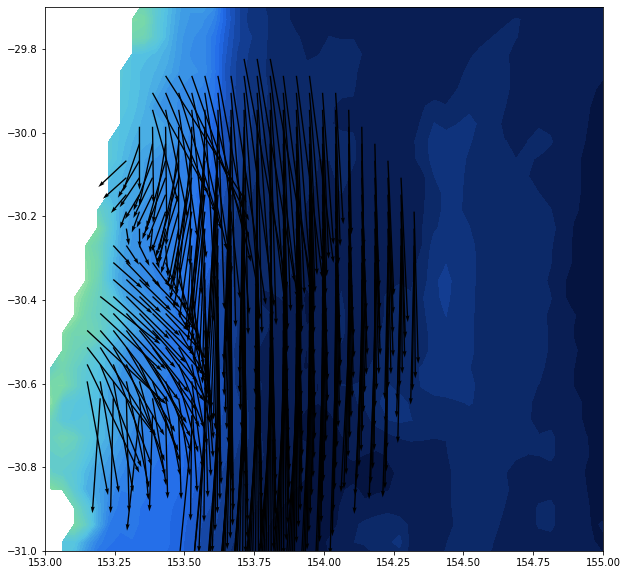

In [8]:
path_chl = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/CHL/'

chl = xr.open_dataset(path_chl+'oc-glo-bio-multi-l4-chl_interpolated_4km_daily_East_Australian_Current_2020_11.nc')
step=3
fig,ax=plt.subplots(figsize=(10,10))
ax.set_xlim(153,155)
ax.set_ylim(-31,-29.7)
ax.contourf(chl['lon'],chl['lat'],np.log10(chl['CHL'][22-1].values),levels=np.linspace(-1.2,.8,50),cmap=cmap_chl)
q=ax.quiver(currents['lon'][::step,::step],
            currents['lat'][::step,::step],
            currents['u'][511-1,::step,::step],
            currents['v'][511-1,::step,::step],units='inches',scale=.5)


# General plots

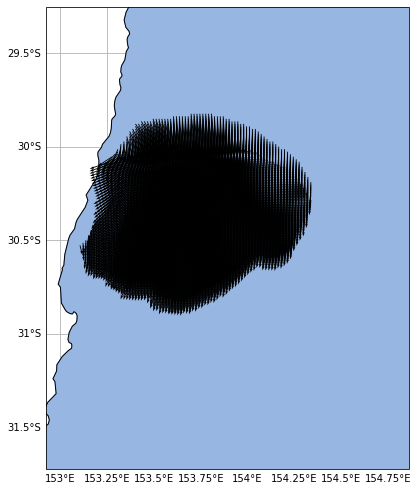

In [9]:
fig,ax=fig_cot_au(1,1)
ax.quiver(currents['lon'],currents['lat'],np.nanmean(currents['u'],axis=0),np.nanmean(currents['v'],axis=0),
          scale=9)

(153.2, 154.4)

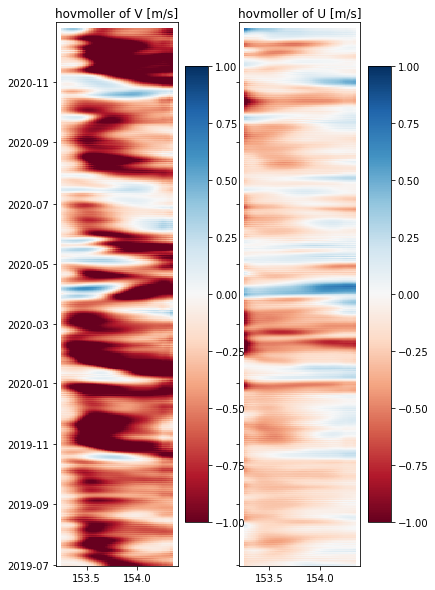

In [10]:
fig,axs=plt.subplots(figsize=(6,10),ncols=2,sharex=True,sharey=True)

pc=axs[0].pcolor(currents['lon'][0,:],currents['time'].values,
           (currents['v'][:,100,:].values),vmin=-1,vmax=1,cmap='RdBu')
axs[0].set_title('hovmoller of V [m/s]')

pc1=axs[1].pcolor(currents['lon'][0,:],currents['time'].values,
           (currents['u'][:,100,:].values),vmin=-1,vmax=1,cmap='RdBu')

axs[1].set_title('hovmoller of U [m/s]')

fig.colorbar(pc,ax=axs[0])
fig.colorbar(pc1,ax=axs[1])

axs[0].set_xlim(153.2,154.4)
axs[1].set_xlim(153.2,154.4)


## Just check that the vectors are well gridded, comparison with example file


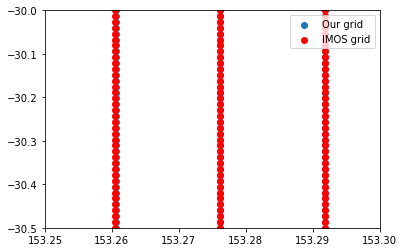

In [11]:
pwd = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data_Processing/Gap_Filling/run_coffs/'
example_file = xr.open_dataset(pwd+'IMOS_ACORN_V_20191002T003000Z_COF_FV01_1-hour-avg.nc')
[lonex,latex] = np.meshgrid(example_file['LONGITUDE'].values,example_file['LATITUDE'].values)
plt.xlim(153.25,153.3)

plt.ylim(-30.5,-30)
plt.scatter(currents['lon'],currents['lat'],label='Our grid')
plt.scatter(lonex,latex,color='r',label='IMOS grid')
plt.legend()